# ANÁLISIS DE SENTIMIENTOS CON REDES LSTM

## 1 - El problema a resolver

Crearemos un modelo LSTM que sea capaz de clasificar una crítica a una película (en formato texto) como positiva o negativa.

## 2 - El set de datos


Usaremos el dataset [IMDB](https://ai.stanford.edu/~amaas/data/sentiment/) (*Internet Movie Database*) que contiene 50.000 críticas a diferentes películas, etiquetadas por sentimiento: 0 para negativos y 1 para positivos.

Algunos ejemplos:

- *a rating of 1 does not begin to express how dull depressing and relentlessly bad this movie is...*. Sentimiento: **NEGATIVO**
- *this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor...* Sentimiento: **POSITIVO**

In [1]:
# Leer el dataset

from keras.datasets import imdb

# Antes de leer debemos tener en cuenta que habrá:
# - Espacios en blanco: índice 0
# - Token (indicador) de inicio de frase: índice 1
# - Token para indicar palabra desconocida: índice 2
# - Token para indicar palabra no usada: índice 3

(x_train, y_train), (x_test, y_test) = imdb.load_data(index_from=3)

2026-04-16 23:57:30.813975: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/isabel/MFC/venv/lib/python3.12/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [2]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(25000,) (25000,)
(25000,) (25000,)


In [3]:
# Cada palabra en un review está representada con un número entero,
# que indica la frecuencia con que la palabra aparece en el dataset
# Por ejemplo, "10" indica que es la décima palabra más común en el
# dataset

print(x_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 19193, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 10311, 8, 4, 107, 117, 5952, 15, 256, 4, 31050, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 12118, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [4]:
# Cada crítica tendrá un tamaño diferente, así que tendremos
# que ajustar todas las secuencias al mismo tamaño
print(len(x_train[0]))
print(len(x_train[200]))

218
160


In [4]:
# Tamaño del vocabulario: ¿cuántas palabras diferentes aparecen
# en el dataset
import numpy as np

TAM_VOCAB = len(np.unique(x_train))
print(f"Tamaño del vocabulario: {TAM_VOCAB} palabras")

Tamaño del vocabulario: 24902 palabras


In [6]:
# Convertir el "review" de su representación numérica a texto

palabra_to_id = imdb.get_word_index()
palabra_to_id = {key:(value+3) for key,value in palabra_to_id.items()}
palabra_to_id["<PAD>"] = 0
palabra_to_id["<START>"] = 1
palabra_to_id["<UNK>"] = 2
palabra_to_id["<UNUSED>"] = 3

# Diccionario inverso: de índices a palabras
id_to_palabra = dict((i, palabra) for (palabra, i) in palabra_to_id.items())

print(palabra_to_id['where'])
print(id_to_palabra[25])

121
you


In [7]:
# Ejemplo de una frase del set de entrenamiento
import textwrap
ID = 159
texto_decodificado = " ".join(id_to_palabra[i] for i in x_train[ID])
print('REVIEW:')
print(textwrap.fill(texto_decodificado,80)+'\n')
print('SENTIMIENTO:')

if y_train[ID]==0:
  print('Negativo')
else:
  print('Positivo')

REVIEW:
<START> a rating of 1 does not begin to express how dull depressing and
relentlessly bad this movie is

SENTIMIENTO:
Negativo


## 3 - El sistema a implementar

![](https://drive.google.com/uc?export=view&id=1xRRRsllKQPim61HFMKiOiVDYyfFDh8w8)

## 4 - Padding con ceros

Las entradas deben tener un tamaño fijo, pero cada secuencia (texto con el sentimiento) tiene un tamaño variable.

Fijaremos el tamaño de cada *review* a 80 palabras:

- Si la secuencia tiene menos de 80 palabras, el resto de los elementos se completará con ceros
- Se truncarán secuencias con más de 80 palabras

In [8]:
from tensorflow.keras.preprocessing import sequence

MAX_LEN = 80 # Máxima longitud de la secuencia
x_train_padded = sequence.pad_sequences(x_train, maxlen=MAX_LEN, padding='post',
                                        truncating='post')
x_test_padded = sequence.pad_sequences(x_test, maxlen=MAX_LEN, padding='post',
                                        truncating='post')
print(x_train.shape)
print(x_train_padded.shape)

(25000,)
(25000, 80)


In [9]:
print(x_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 19193, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 10311, 8, 4, 107, 117, 5952, 15, 256, 4, 31050, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 12118, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [10]:
print(x_train_padded[0,:])

[    1    14    22    16    43   530   973  1622  1385    65   458  4468
    66  3941     4   173    36   256     5    25   100    43   838   112
    50   670 22665     9    35   480   284     5   150     4   172   112
   167 21631   336   385    39     4   172  4536  1111    17   546    38
    13   447     4   192    50    16     6   147  2025    19    14    22
     4  1920  4613   469     4    22    71    87    12    16    43   530
    38    76    15    13  1247     4    22    17]


## 5 - Word embeddings

En lugar de representar cada palabra como un vector one-hot de 24902 elementos (el tamaño del vocabulario), resulta más eficiente entrenar una pequeña Red Neuronal que represente de forma compacta (128 elementos) cada palabra.

Esta representación compacta se conoce como **embedding** y palabras similares tendrán *embeddings* similares:

![](https://drive.google.com/uc?export=view&id=1YjgUt4VF_bFkzADjdr-gABkKXHUOVub-)

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
import tensorflow as tf

# Semilla de los generadores aleatorios
SEED = 32
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Parámetros del embedding
INPUT_DIM = TAM_VOCAB    # El tamaño del vocabulario
OUTPUT_DIM = 64          # Tamaño de cada vector codificado por el word embedding
INPUT_LENGTH = MAX_LEN   # La longitud (número de elementos) de cada secuencia

# Creación del modelo y adición del embedding
modelo = Sequential()
modelo.add(Embedding(input_dim=INPUT_DIM, output_dim=OUTPUT_DIM,
                     input_length=INPUT_LENGTH))

/home/isabel/MFC/venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


## 6 - El modelo: red LSTM y capa de salida

In [12]:
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.models import Sequential

UNITS = 64 # Tamaño de la celda de memoria (c_t) y del estado oculto (h_(t-1))
LSTM_DROPOUT = 0.30
LSTM_RECURRENT_DROPOUT = 0.20

# Reconstruir el modelo desde cero para evitar acumular capas en re-ejecuciones
modelo = Sequential()
modelo.add(Embedding(
    input_dim=INPUT_DIM,
    output_dim=OUTPUT_DIM,
    input_length=INPUT_LENGTH
))
modelo.add(LSTM(
    UNITS,
    dropout=LSTM_DROPOUT,
    recurrent_dropout=LSTM_RECURRENT_DROPOUT
))

# Capa de salida (clasificación de sentimientos)
modelo.add(Dense(1, activation='sigmoid'))

2026-04-16 23:58:25.067635: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Número de parámetros del modelo:

#### Embedding

- El dato de entrada será del mismo tamaño del vocabulario (24.902 elementos) y la salida será de 128. Para esta capa se deben entrenar 24902x128 = 3'187.456 parámetros

#### Red LSTM

- Las compuertas "olvidar", "entrada", "salida" y "candidata" son pequeñas redes neuronales cuya salida es de la forma:
$f\left( \bar{W_x}\bar{x_t} + \bar{W_h}\bar{h_{t-1}} + \bar{b} \right)$
- En este caso:
  - $\bar{x_t}$ (dato de entrada): 128x1 (pues el *embedding* genera vectores de 128 elementos)
  - $\bar{h_{t-1}}$, $\bar{c_t}$ (estado oculto, celda de memoria): 128x1 (pues la variable ``UNITS`` de la red LSTM es 128)
- Los coeficientes de cada compuerta y de la celda candidata tendrán estos tamaños:
  - $\bar{W_x}$: 128x128 = 16.384 parámetros
  - $\bar{W_h}$: 128x128 = 16.384 parámetros
  - $\bar{b}$: 128x1  = 128 parámetros
- En total cada elemento requiere el entrenamiento de 16.384 + 16.384 + 128 = 32.896 parámetros.
- Al tener cuatro de estos elementos se requerirán 4x32.896 = 131.584 parámetros

#### Capa de salida:
- El dato de entrada será de 128 elementos (la salida de la red LSTM) y a la salida se tendrá una única neurona (clasificación softmax).
- El número total de parámetros será: 128x1 (Ws) + 1 (b) = 129

In [13]:
modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 7 - Entrenamiento del modelo

In [ ]:
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

optimizador = RMSprop(learning_rate=0.0003)
modelo.compile(loss='binary_crossentropy', optimizer=optimizador, metrics=['accuracy'])

BATCH_SIZE = 64
EPOCHS = 20
x_train_padded = np.clip(x_train_padded, 0, INPUT_DIM - 1)
x_test_padded = np.clip(x_test_padded, 0, INPUT_DIM - 1)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)

historia = modelo.fit(
    x_train_padded,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_test_padded, y_test),
    callbacks=[early_stopping, reduce_lr]
 )

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 51s 121ms/step - accuracy: 0.5543 - loss: 0.6828 - val_accuracy: 0.6969 - val_loss: 0.6008 - learning_rate: 3.0000e-04
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 53s 135ms/step - accuracy: 0.7388 - loss: 0.5657 - val_accuracy: 0.7776 - val_loss: 0.5030 - learning_rate: 3.0000e-04
Epoch 3/20
362/391 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.7938 - loss: 0.4837

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Curvas de accuracy
acc_train = historia.history['accuracy']
acc_test = historia.history['val_accuracy']
epocas = range(1, len(acc_train) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epocas, acc_train, 'o-', label='Train accuracy')
plt.plot(epocas, acc_test, 's-', label='Test accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Train vs Test accuracy')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 7.1 - Búsqueda de hiperparámetros (random search simple)

Sí, es posible realizar búsqueda de hiperparámetros. A continuación se muestra una versión ligera de random search para probar combinaciones y elegir la mejor por `val_accuracy`.

In [23]:
import random
import itertools
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import EarlyStopping

def crear_modelo(input_dim, input_length, output_dim, units, lr, dropout, recurrent_dropout):
    m = Sequential()
    m.add(Embedding(input_dim=input_dim, output_dim=output_dim, input_length=input_length))
    m.add(LSTM(units, dropout=dropout, recurrent_dropout=recurrent_dropout))
    m.add(Dense(1, activation='sigmoid'))
    m.compile(
        loss='binary_crossentropy',
        optimizer=RMSprop(learning_rate=lr),
        metrics=['accuracy']
    )
    return m

# Subconjunto para acelerar la búsqueda
MAX_SAMPLES = 12000
idx = np.random.permutation(len(x_train_padded))[:MAX_SAMPLES]
x_search = x_train_padded[idx]
y_search = y_train[idx]

split = int(0.8 * len(x_search))
x_tr, x_val = x_search[:split], x_search[split:]
y_tr, y_val = y_search[:split], y_search[split:]

espacio = {
    'output_dim': [64, 128],
    'units': [64, 128],
    'lr': [1e-3, 5e-4, 1e-4],
    'dropout': [0.2, 0.3, 0.4],
    'recurrent_dropout': [0.1, 0.2]
}

combinaciones = list(itertools.product(
    espacio['output_dim'],
    espacio['units'],
    espacio['lr'],
    espacio['dropout'],
    espacio['recurrent_dropout']
))

MAX_TRIALS = 8
trials = random.sample(combinaciones, k=min(MAX_TRIALS, len(combinaciones)))

resultados = []
for i, (out_dim, units, lr, dr, rdr) in enumerate(trials, start=1):
    print(f"\nTrial {i}/{len(trials)} -> out_dim={out_dim}, units={units}, lr={lr}, dropout={dr}, rec_dropout={rdr}")
    modelo_tmp = crear_modelo(
        input_dim=INPUT_DIM,
        input_length=INPUT_LENGTH,
        output_dim=out_dim,
        units=units,
        lr=lr,
        dropout=dr,
        recurrent_dropout=rdr
    )

    es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=0)
    h = modelo_tmp.fit(
        x_tr,
        y_tr,
        validation_data=(x_val, y_val),
        epochs=8,
        batch_size=128,
        callbacks=[es],
        verbose=0
    )

    best_val_acc = float(np.max(h.history['val_accuracy']))
    best_val_loss = float(np.min(h.history['val_loss']))

    resultados.append({
        'output_dim': out_dim,
        'units': units,
        'lr': lr,
        'dropout': dr,
        'recurrent_dropout': rdr,
        'best_val_accuracy': best_val_acc,
        'best_val_loss': best_val_loss
    })

resultados = sorted(resultados, key=lambda x: x['best_val_accuracy'], reverse=True)
print("\nTop 3 configuraciones:")
for r in resultados[:3]:
    print(r)

mejor = resultados[0]
print("\nMejor configuración encontrada:")
print(mejor)


Trial 1/8 -> out_dim=64, units=128, lr=0.0001, dropout=0.4, rec_dropout=0.2

Trial 2/8 -> out_dim=128, units=128, lr=0.0001, dropout=0.4, rec_dropout=0.2

Trial 3/8 -> out_dim=128, units=64, lr=0.0001, dropout=0.3, rec_dropout=0.2

Trial 4/8 -> out_dim=128, units=64, lr=0.001, dropout=0.2, rec_dropout=0.1

Trial 5/8 -> out_dim=128, units=128, lr=0.0005, dropout=0.3, rec_dropout=0.1

Trial 6/8 -> out_dim=128, units=64, lr=0.0005, dropout=0.2, rec_dropout=0.2

Trial 7/8 -> out_dim=64, units=128, lr=0.0005, dropout=0.3, rec_dropout=0.1

Trial 8/8 -> out_dim=128, units=64, lr=0.0001, dropout=0.3, rec_dropout=0.1

Top 3 configuraciones:
{'output_dim': 64, 'units': 128, 'lr': 0.0005, 'dropout': 0.3, 'recurrent_dropout': 0.1, 'best_val_accuracy': 0.8133333325386047, 'best_val_loss': 0.4383408725261688}
{'output_dim': 128, 'units': 64, 'lr': 0.0005, 'dropout': 0.2, 'recurrent_dropout': 0.2, 'best_val_accuracy': 0.8087499737739563, 'best_val_loss': 0.43946048617362976}
{'output_dim': 128, 'uni

## 7.2 - Entrenamiento por épocas con el mejor modelo encontrado

Entrenamos nuevamente usando la mejor configuración hallada en la búsqueda (`mejor`) y comparamos `accuracy` de entrenamiento y prueba por época.

Configuración usada para reentrenar: {'output_dim': 64, 'units': 64, 'lr': 0.0003, 'dropout': 0.4, 'recurrent_dropout': 0.2, 'best_val_accuracy': 0.8133333325386047, 'best_val_loss': 0.4383408725261688}
Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 59s 212ms/step - accuracy: 0.5201 - loss: 0.6920 - val_accuracy: 0.5547 - val_loss: 0.6916
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 34s 172ms/step - accuracy: 0.6200 - loss: 0.6607 - val_accuracy: 0.7108 - val_loss: 0.5871
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 37s 187ms/step - accuracy: 0.7413 - loss: 0.5704 - val_accuracy: 0.7606 - val_loss: 0.5177
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 39s 198ms/step - accuracy: 0.7946 - loss: 0.4979 - val_accuracy: 0.7948 - val_loss: 0.4442
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 38s 191ms/step - accuracy: 0.8197 - loss: 0.4419 - val_accuracy: 0.7819 - val_loss: 0.4787
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 38s 192ms/step - accuracy: 0.8355 - loss: 0.4068 - val_accuracy: 0.8053 - val_loss: 0.4432
Epoch 7/20


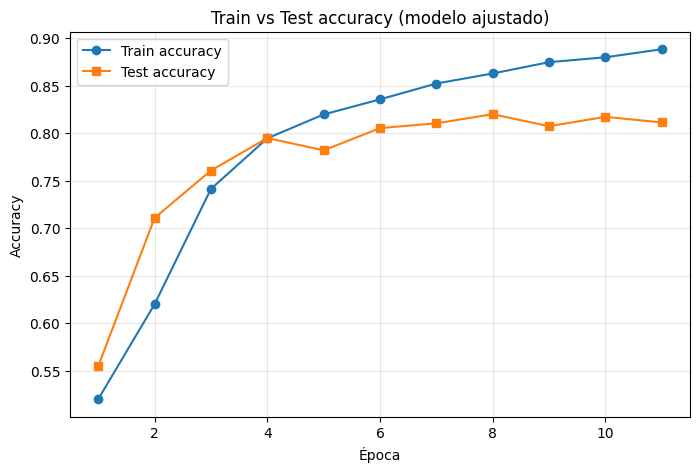

Accuracy final train: 0.8883
Accuracy final test:  0.8112
Diferencia final (train - test): 0.0771


In [28]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Tomar la mejor configuración encontrada en el random search
best_cfg = mejor.copy()

# Ajuste manual para reducir overfitting
best_cfg['units'] = 64
best_cfg['dropout'] = 0.4
best_cfg['recurrent_dropout'] = 0.2
best_cfg['lr'] = 3e-4

print('Configuración usada para reentrenar:', best_cfg)

# Reconstruir el mejor modelo
modelo_mejor = Sequential()
modelo_mejor.add(Embedding(
    input_dim=INPUT_DIM,
    output_dim=best_cfg['output_dim'],
    input_length=INPUT_LENGTH
))
modelo_mejor.add(LSTM(
    best_cfg['units'],
    dropout=best_cfg['dropout'],
    recurrent_dropout=best_cfg['recurrent_dropout']
))
modelo_mejor.add(Dense(1, activation='sigmoid'))
modelo_mejor.compile(
    loss='binary_crossentropy',
    optimizer=RMSprop(learning_rate=best_cfg['lr']),
    metrics=['accuracy']
 )

# Entrenamiento por épocas para comparar curvas train vs test
EPOCHS_BEST = 20
BATCH_SIZE_BEST = 128

es_best = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
 )

historia_best = modelo_mejor.fit(
    x_train_padded,
    y_train,
    validation_data=(x_test_padded, y_test),
    epochs=EPOCHS_BEST,
    batch_size=BATCH_SIZE_BEST,
    callbacks=[es_best],
    verbose=1
 )

# Curvas de accuracy
acc_train = historia_best.history['accuracy']
acc_test = historia_best.history['val_accuracy']
epocas = range(1, len(acc_train) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epocas, acc_train, 'o-', label='Train accuracy')
plt.plot(epocas, acc_test, 's-', label='Test accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Train vs Test accuracy')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Resumen numérico
gap_final = acc_train[-1] - acc_test[-1]
print(f'Accuracy final train: {acc_train[-1]:.4f}')
print(f'Accuracy final test:  {acc_test[-1]:.4f}')
print(f'Diferencia final (train - test): {gap_final:.4f}')


## 8 - Predicción con el modelo entrenado

In [24]:
# Tomemos un dato de prueba y verifiquemos si lo clasifica correctamente
# Podemos probar con el dato 25 (POSITIVO), el 5 (POSITIVO) o el 15 (NEGATIVO),
# por ejemplo
ID = 5
texto_decodificado = " ".join(id_to_palabra[i] for i in x_test_padded[ID])
print(textwrap.fill(texto_decodificado,80))

<START> i'm absolutely disgusted this movie isn't being sold all who love this
movie should email disney and increase the demand for it they'd eventually have
to sell it then i'd buy copies for everybody i know everything and everybody in
this movie did a good job and i haven't figured out why disney hasn't put this
movie on dvd or on vhs in rental stores at least i haven't seen any copies this
is a wicked good movie and should be seen by all the kids in the new generation
don't get to see it and i think they


In [ ]:
# Predicción (usar x_test_padded)
prob = modelo.predict(x_test_padded[ID,:].reshape(1, INPUT_LENGTH))
if prob<=0.5:
  print('Sentimiento: NEGATIVO')
else:
  print('Sentimiento: POSITIVO')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Sentimiento: POSITIVO
